In [1]:
import pandas as pd
import numpy as np
import pickle
import os

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [3]:
from data_preprocessing import load_and_clean
from feature_engineering import build_features, FEATURE_COLS, TARGET_COL

In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [5]:
BASE_DIR = os.getcwd()

DATA_PATH   = os.path.join(BASE_DIR, '..', 'datasets', 'student_progress.csv')
MODEL_PATH  = os.path.join(BASE_DIR, 'model.pkl')
SCALER_PATH = os.path.join(BASE_DIR, 'scaler.pkl')

In [7]:
def train():
    df = load_and_clean()
    df = build_features(df)

    X = df[FEATURE_COLS].fillna(0)
    y = df[TARGET_COL]
#--------------------TRAIN TEST SPLIT------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # scale for logistic regression but keep raw for RF
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # logistic regression as baseline
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train_scaled, y_train)
    lr_preds = lr.predict(X_test_scaled)
    lr_acc = accuracy_score(y_test, lr_preds)

    # random forest - usually stronger for this kind of tabular data
    rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_preds = rf.predict(X_test)
    rf_acc = accuracy_score(y_test, rf_preds)

    print(f"Logistic Regression Accuracy: {lr_acc:.4f}")
    print(f"Random Forest Accuracy:       {rf_acc:.4f}")

    # pick the better model
    if rf_acc >= lr_acc:
        best_model = rf
        best_preds = rf_preds
        best_X_test = X_test
        print("\nUsing Random Forest")
    else:
        best_model = lr
        best_preds = lr_preds
        best_X_test = X_test_scaled
        print("\nUsing Logistic Regression")

    print("\nClassification Report:")
    print(classification_report(y_test, best_preds, target_names=['Fail', 'Pass']))

    # cross-validation on full dataset to confirm no overfitting
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if best_model is rf:
        cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')
    else:
        from sklearn.pipeline import make_pipeline
        pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
        cv_scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')

    print(f"\n5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    # feature importance (RF gives this directly)
    if best_model is rf:
        importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS)
        importances = importances.sort_values(ascending=False)
        print("\nTop Feature Importances:")
        print(importances.to_string())

      #  Confusion matrix 
    cm = confusion_matrix(y_test, best_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail', 'Pass'])
    disp.plot()
    plt.savefig('confusion_matrix.png')   

    # save model and scaler for inference
    with open(MODEL_PATH, 'wb') as f:
        pickle.dump(best_model, f)
    with open(SCALER_PATH, 'wb') as f:
        pickle.dump(scaler, f)



    return best_model, scaler, {
        'accuracy': accuracy_score(y_test, best_preds),
        'precision': precision_score(y_test, best_preds),
        'recall': recall_score(y_test, best_preds),
        'f1': f1_score(y_test, best_preds),
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'feature_importances': importances.to_dict() if best_model is rf else {},
   
    }

Logistic Regression Accuracy: 0.8916
Random Forest Accuracy:       0.8327

Using Logistic Regression

Classification Report:
              precision    recall  f1-score   support

        Fail       0.92      0.76      0.83       566
        Pass       0.88      0.97      0.92      1012

    accuracy                           0.89      1578
   macro avg       0.90      0.86      0.88      1578
weighted avg       0.89      0.89      0.89      1578


5-Fold CV Accuracy: 0.8956 ± 0.0058


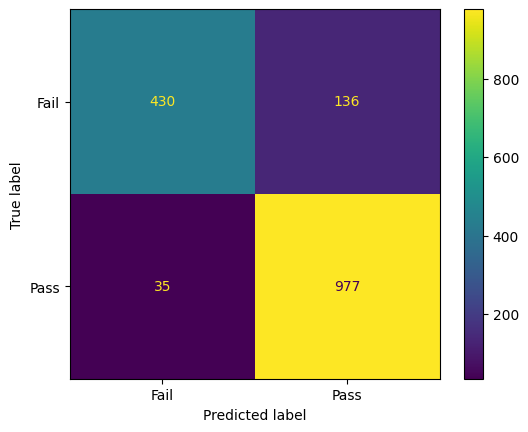

In [8]:
if __name__ == '__main__':
    train()